## Import dependencies and dot env file

In [1]:
from dotenv import load_dotenv
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

c:\Users\fkeyu\Documents\MyCode\Python\space-titanic-problem\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

### Get raw data from kaggle APIs

In [3]:
# Download latest version
path = kagglehub.competition_download('spaceship-titanic',output_dir=r"../data/raw/",force_download=True)

print("Path to competition files:", path)

100%|██████████| 299k/299k [00:00<00:00, 333kB/s]

Extracting files...
Path to competition files: ../data/raw/


## Exploratory data analysis

In [4]:
# load the data into a dataframe

raw_train_df = pd.read_csv("../data/raw/train.csv")
raw_train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
print(f"shape of raw_train_df: {raw_train_df.shape}\n")
print(f"columns in raw_train_df: ")
raw_train_df.columns.to_list()

# 'Transportted' is the target column

shape of raw_train_df: (8693, 14)

columns in raw_train_df: 


['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [6]:
# get the summary of raw_train_df

raw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [7]:
# get descriptive stats of numerical columns in raw_train_df

raw_train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [8]:
# missing values by column in raw_train_df

raw_train_df.isnull().sum(axis=0).sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [9]:
print(f"Total number of missing values in raw_train_df: {raw_train_df.isnull().sum().sum()}")

Total number of missing values in raw_train_df: 2324


In [10]:
# getting dtypes present in raw_train_df

list(set(raw_train_df.dtypes.to_list()))

[dtype('bool'),
 dtype('O'),
 dtype('float64'),
 <StringDtype(storage='python', na_value=nan)>]

In [11]:
raw_train_df_num = raw_train_df.select_dtypes(include=['float64'])

### EDA for numerical columns

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

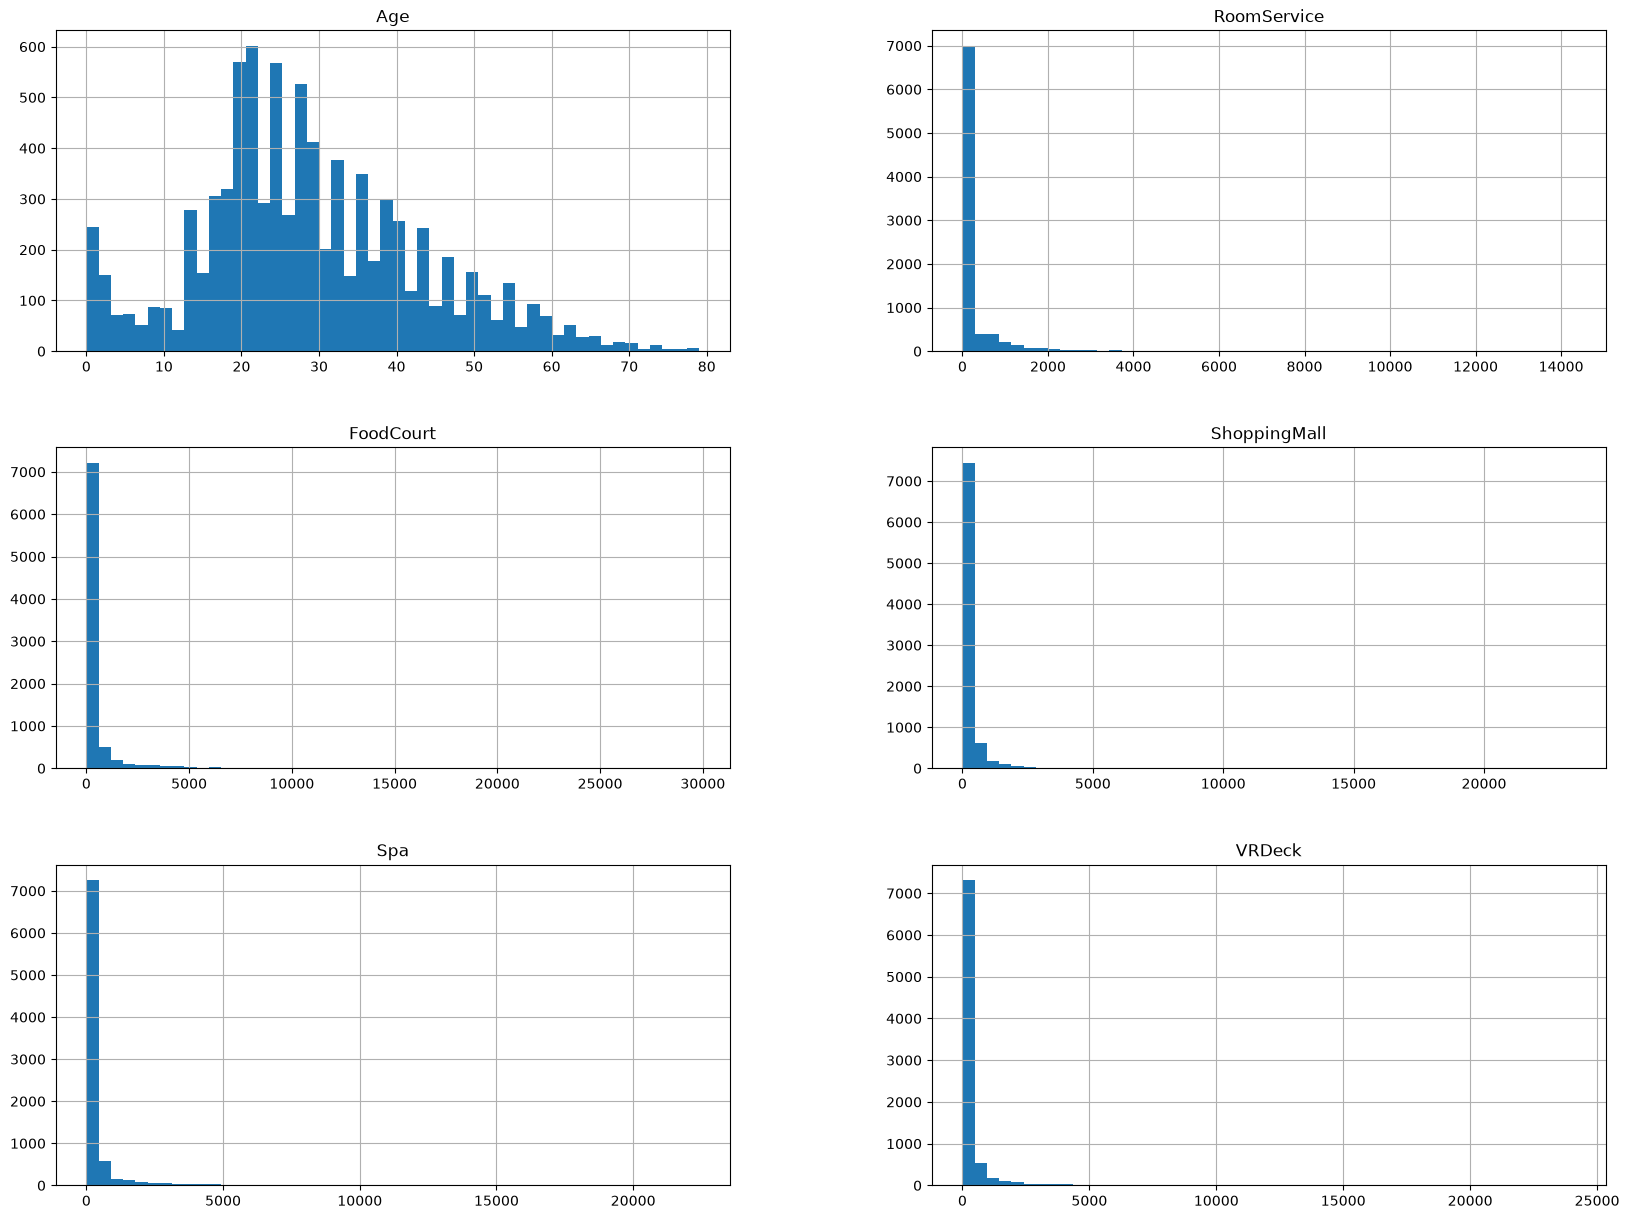

In [12]:
# vizualizing nnumerical columns of the raw_train_df

raw_train_df_num.hist(bins=50, figsize=(20,15))

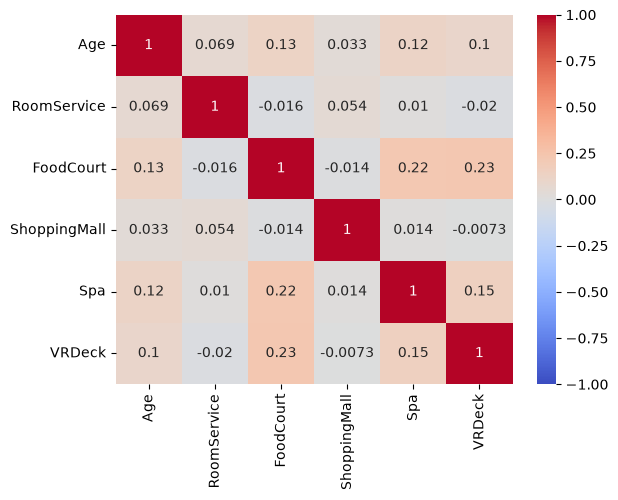

In [13]:
# visualizing correlation between numerical columns

corr_matrix = raw_train_df_num.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [14]:
# no significant correlation between numerical columns found

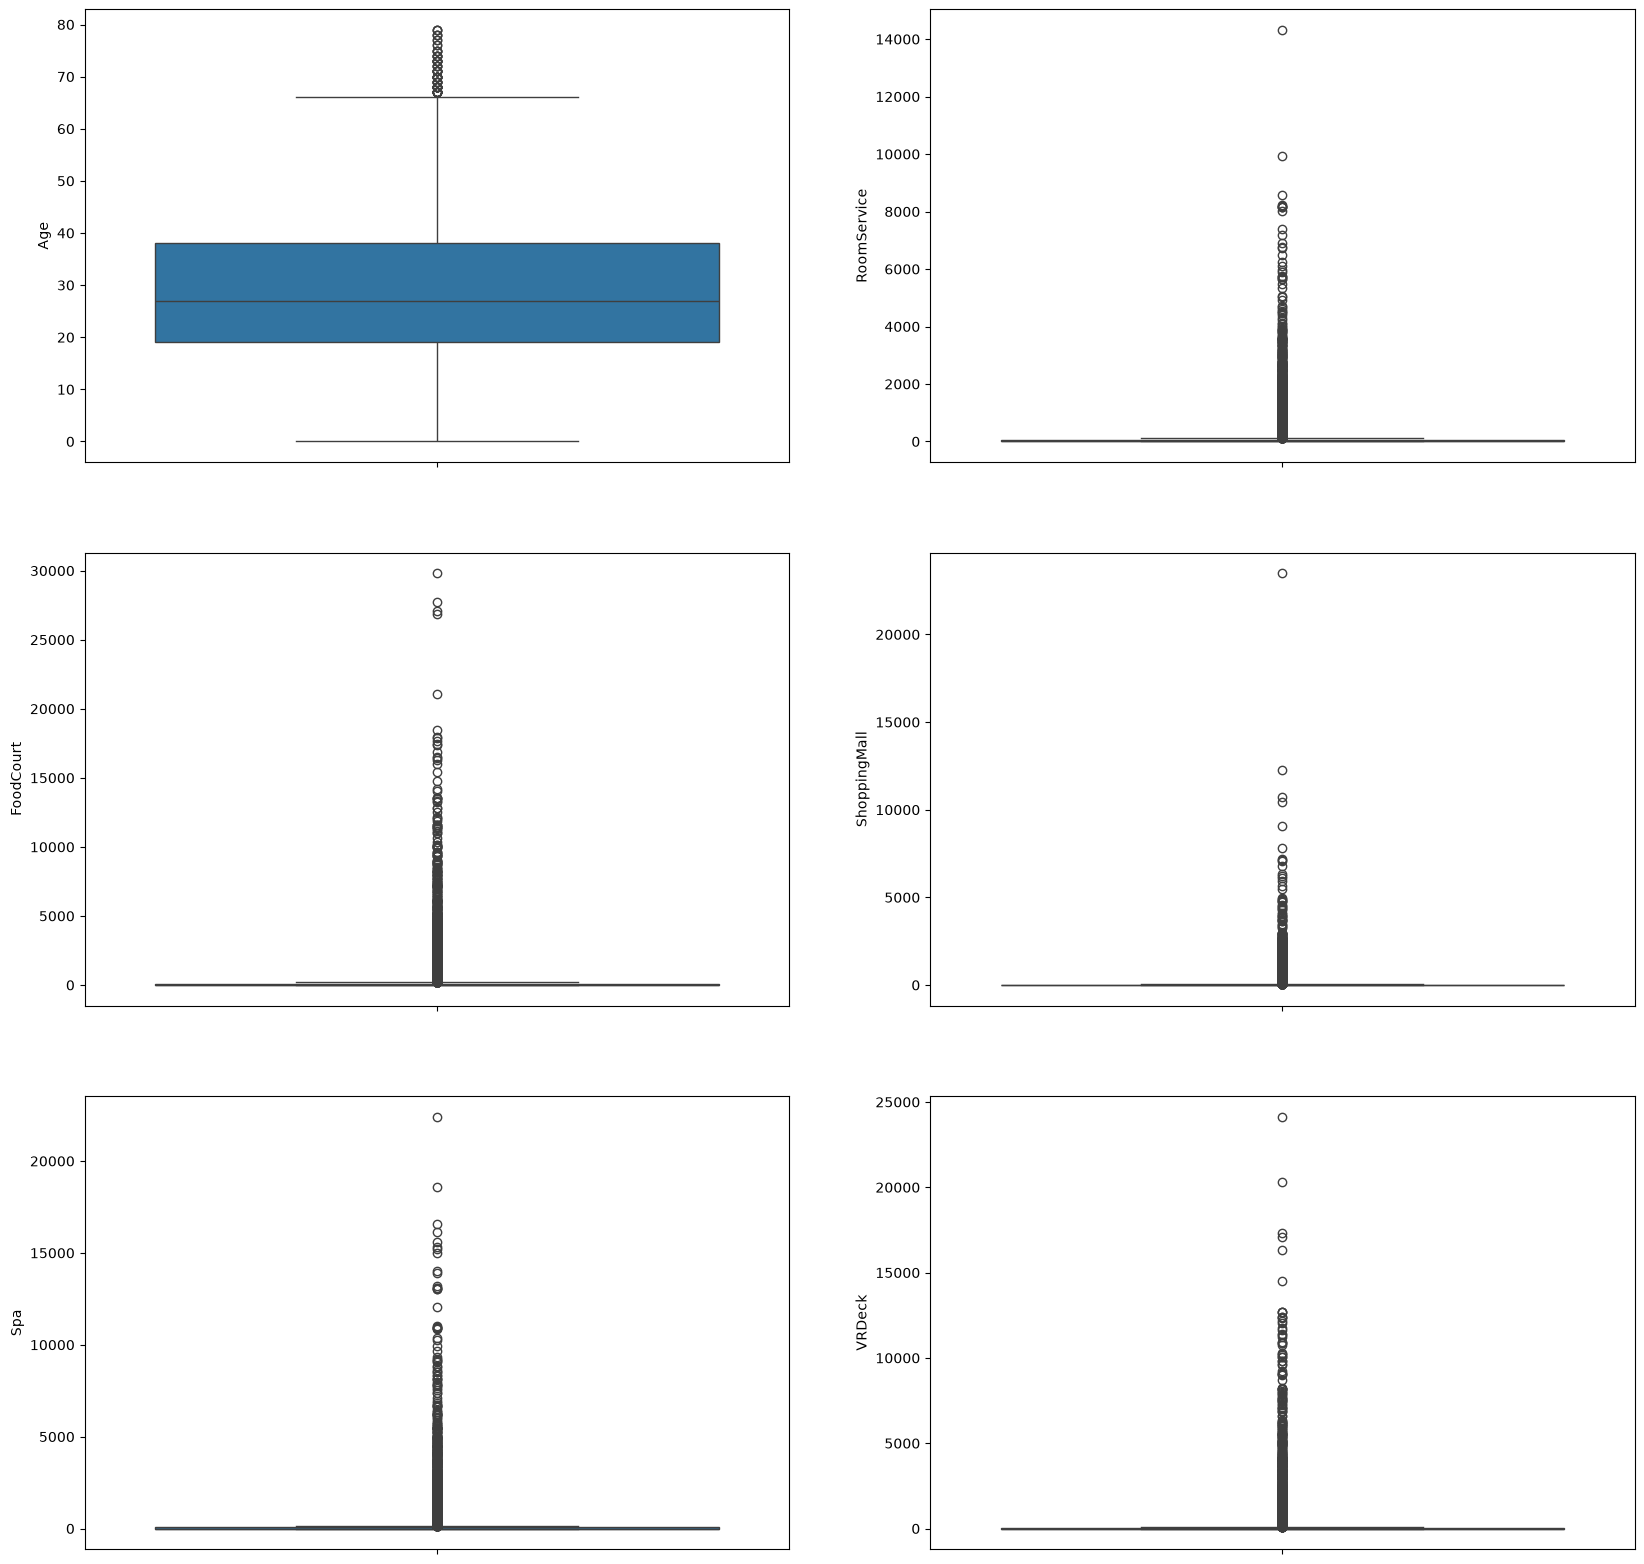

In [15]:
# box plots for numerical columns in raw_train_df

fig, axes = plt.subplots(3,2,figsize=(20,20))

for i in range(len(raw_train_df_num.columns)):
    sns.boxplot(data=raw_train_df_num.iloc[:,i], ax=axes[i//2,i%2])

In [16]:
# apart from age, all other numerical columns are having IQR range 0 
# (i.e., 25th and 75th percentiles are having same value, which is 0 in this case)
# these columns are better transformed (lets try log1p transform)

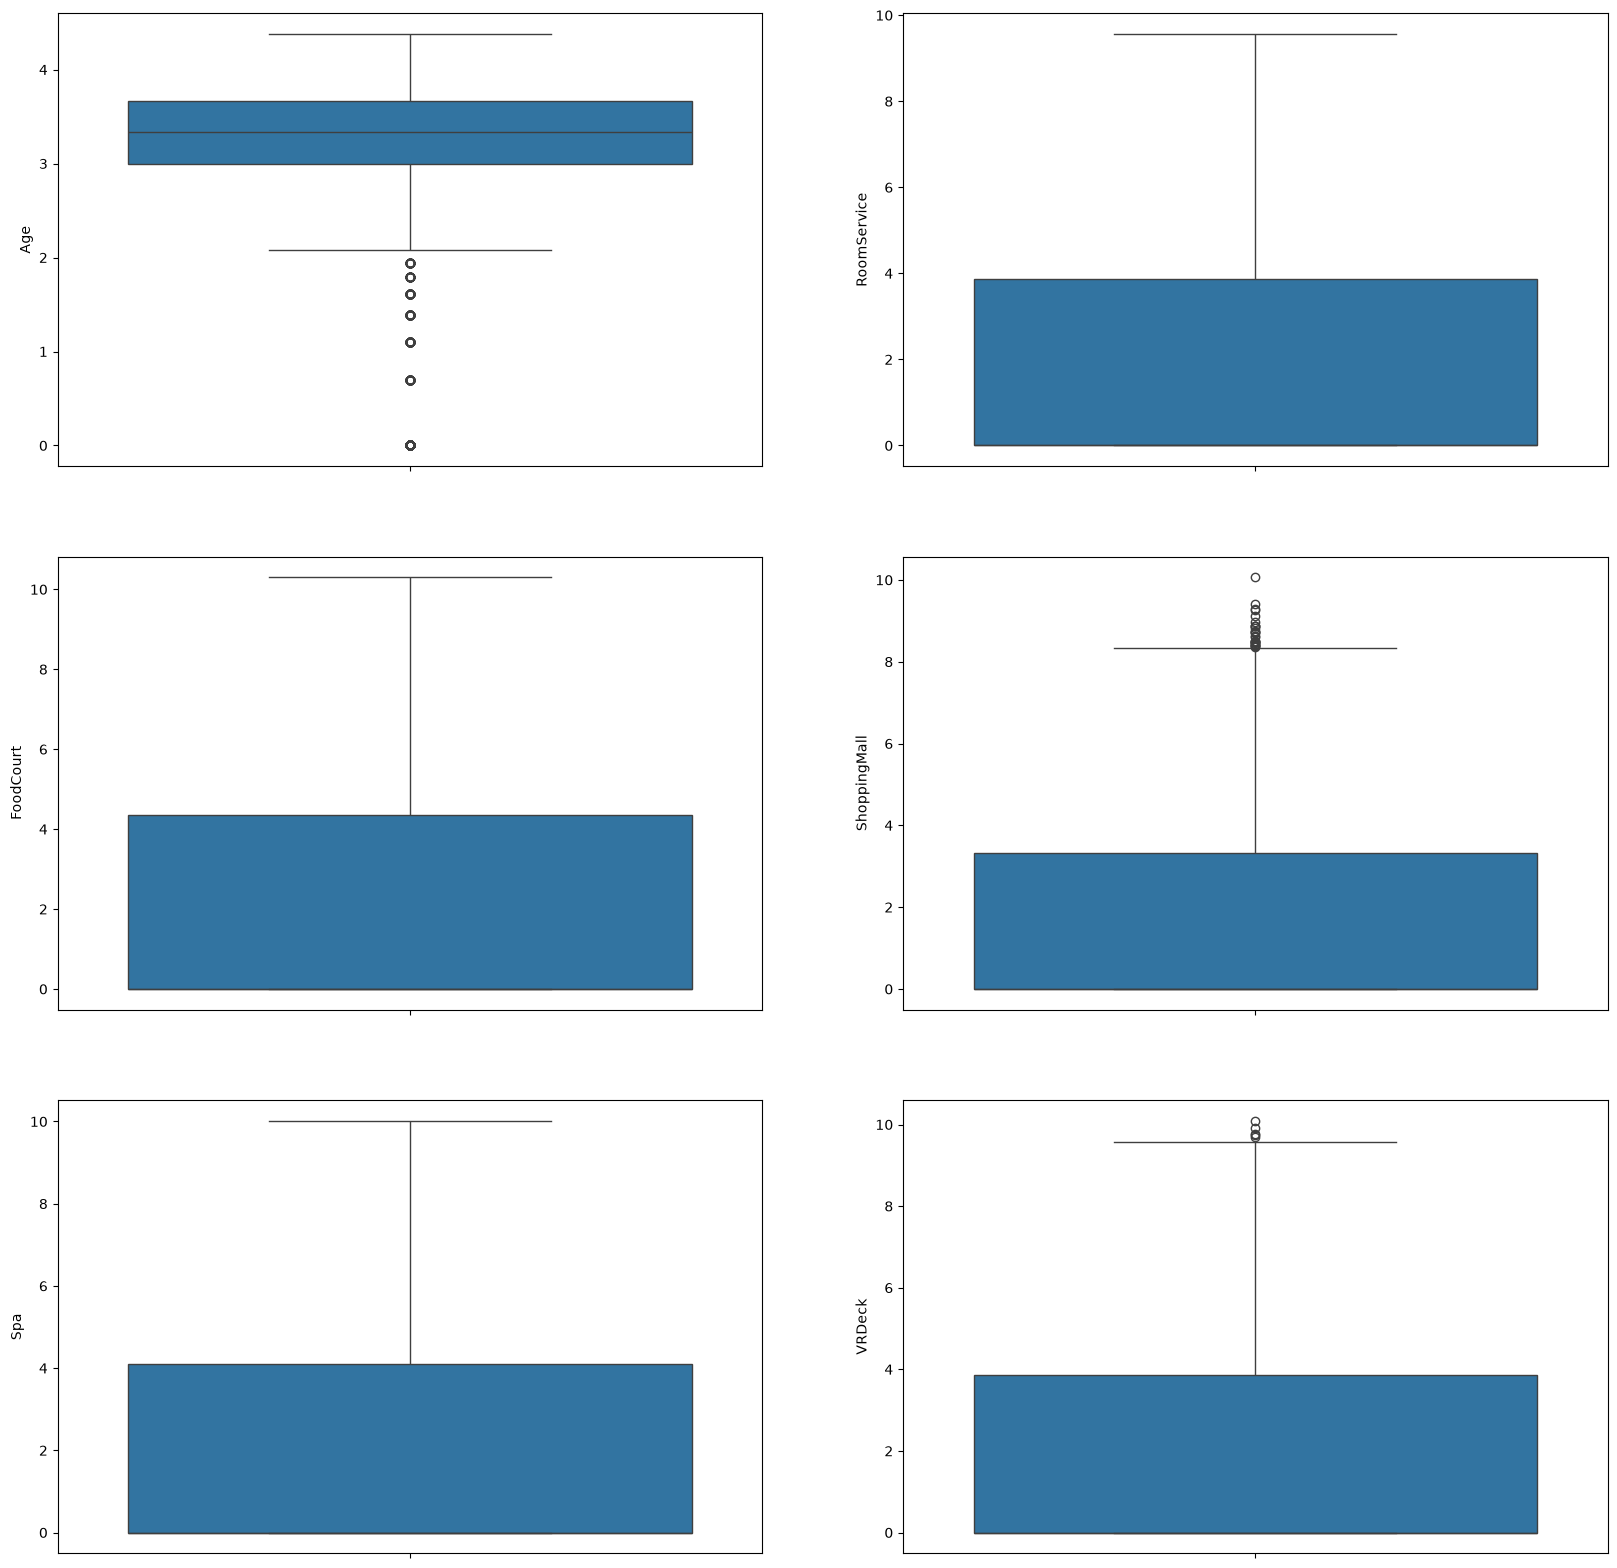

In [17]:
# box plots for numerical columns in raw_train_df with log1p transform

fig, axes = plt.subplots(3,2,figsize=(20,20))

for i in range(len(raw_train_df_num.columns)):
    sns.boxplot(data=np.log1p(raw_train_df_num.iloc[:,i]),ax=axes[i//2,i%2])

# looking much better, also the values are now more or less on the same scale

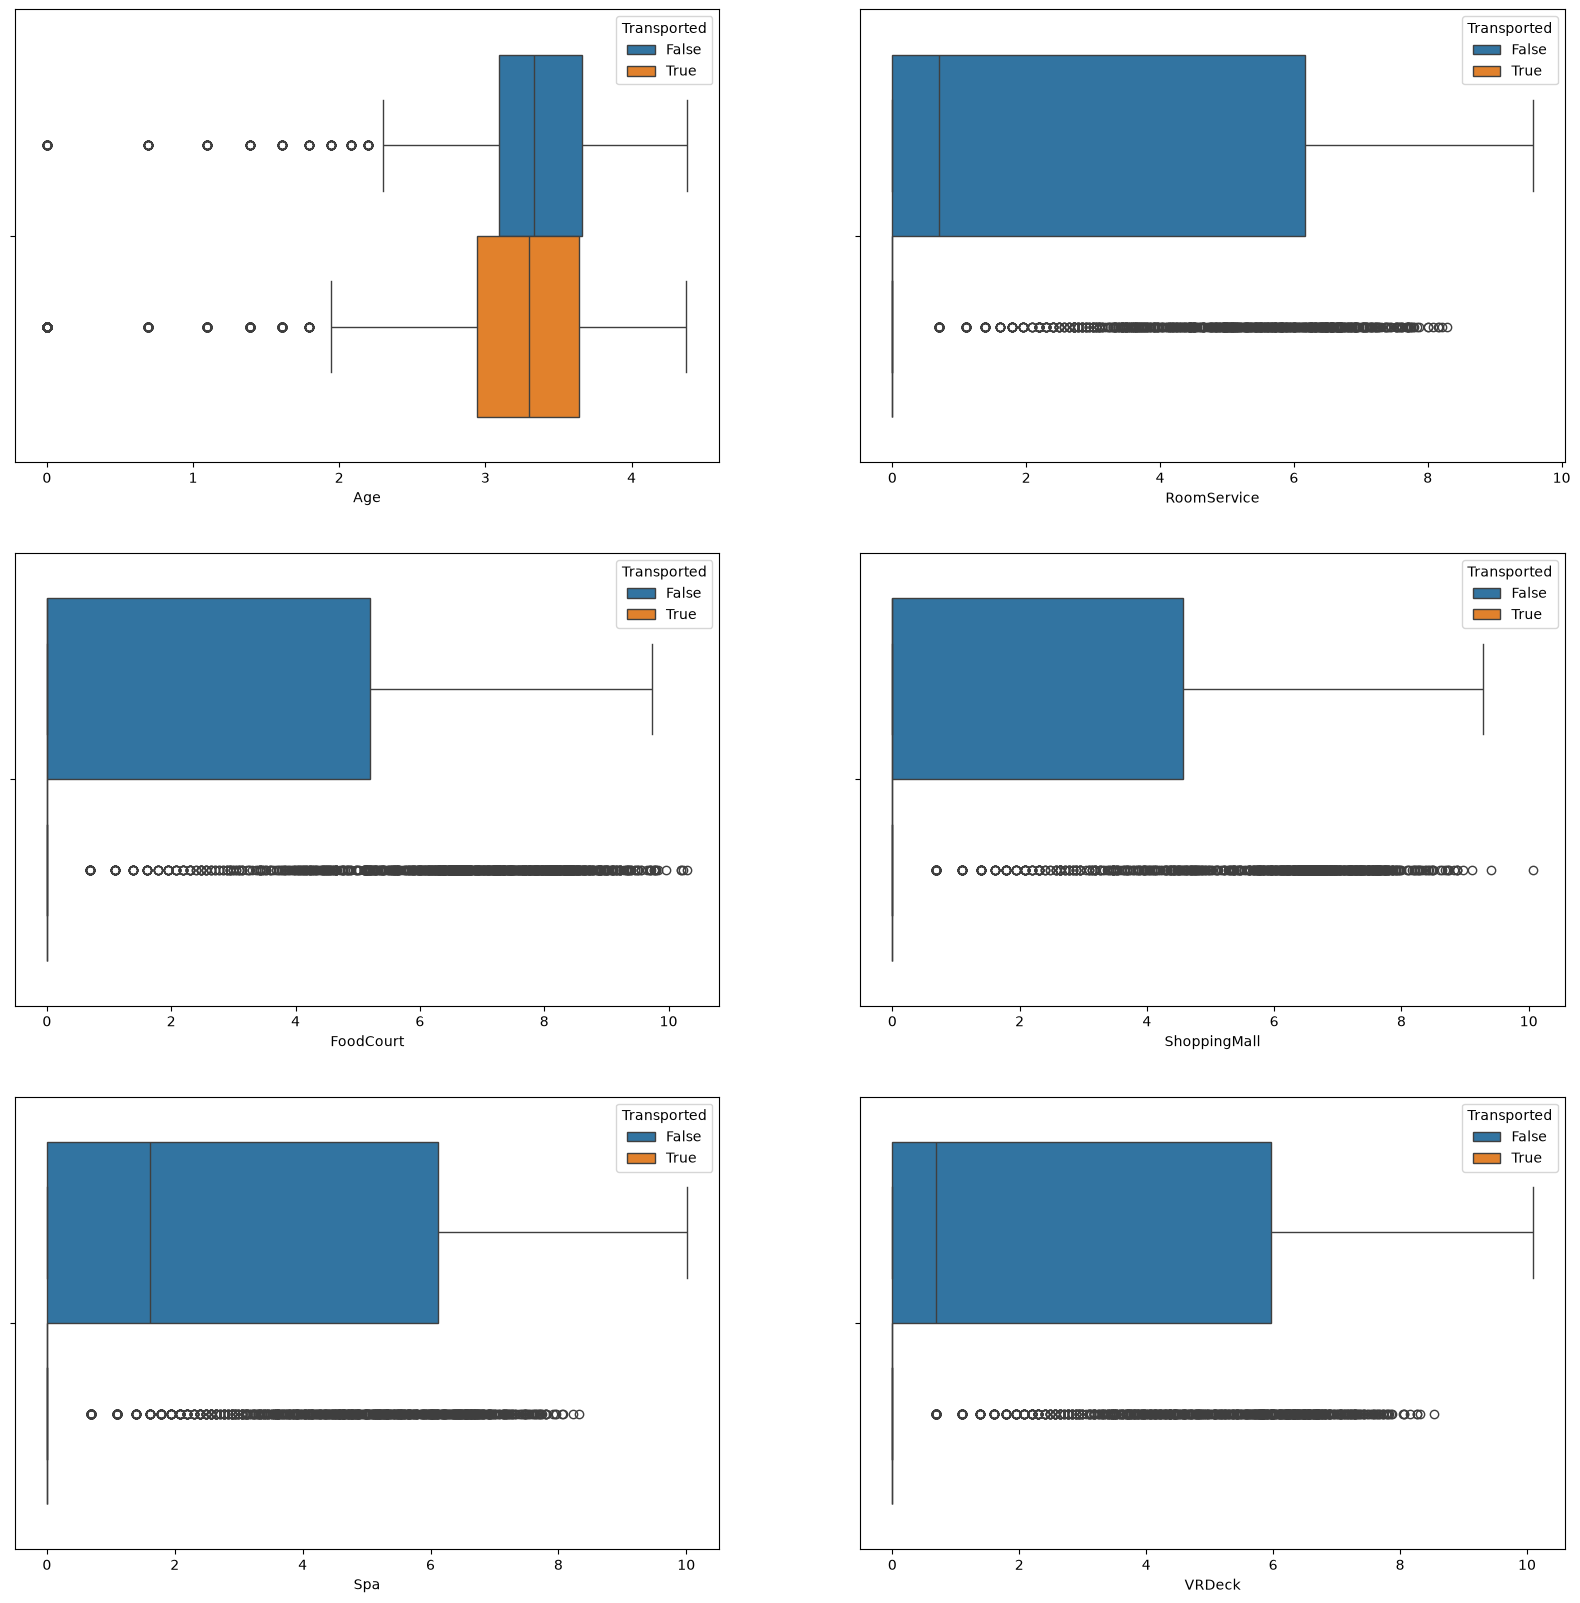

In [18]:
# visualize transformed numerical columns with target variable 

fig, axes = plt.subplots(3,2,figsize=(20,20))

for i in range(len(raw_train_df_num.columns)):
    sns.boxplot(x=np.log1p(raw_train_df.loc[:,raw_train_df_num.columns[i]]),hue='Transported',data=raw_train_df,ax=axes[i//2,i%2])

In [19]:
# this tells an interesting story
# for transported = true, apart from age most numerical columns are having a transformed value of 0 up until 75th percentile

### EDA for categorical columns

In [20]:
# categorical cols from raw_train_df

raw_train_df_cat = raw_train_df.select_dtypes(exclude=['float64'])

In [21]:
raw_train_df_cat.Cabin.describe()

count        8494
unique       6560
top       G/734/S
freq            8
Name: Cabin, dtype: object

In [22]:
# null value count in 'Cabin' column is 199

raw_train_df_cat.Cabin.isnull().sum()

np.int64(199)

In [23]:
# hence all non-null values have 2 fwd slashes (since this cell returns a blank series)

raw_train_df_cat.Cabin[pd.notnull(raw_train_df_cat.Cabin) & ~(raw_train_df_cat.Cabin.str.count('/') == 2)]

Series([], Name: Cabin, dtype: str)

In [24]:
Cabin_list = raw_train_df.Cabin.apply(lambda x: x.split('/') if pd.notnull(x) and x.count('/') == 2 else [None,None,None])
raw_train_df['CabinDeck'] = Cabin_list.apply(lambda x: x[0])
raw_train_df['CabinNum'] = Cabin_list.apply(lambda x: float(x[1]) if x[1] is not None else None)
raw_train_df['CabinSide'] = Cabin_list.apply(lambda x: x[2])   

In [25]:
raw_train_df_cat = raw_train_df.select_dtypes(exclude=['float64'])
cat_cols = raw_train_df_cat.columns.to_list()

cat_cols.remove('PassengerId') # not needed for training
cat_cols.remove('Name') # not needed for training
cat_cols.remove('Transported') # target variable
cat_cols.remove('Cabin') # this col is transformed into 3 new cols

print(cat_cols)

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']


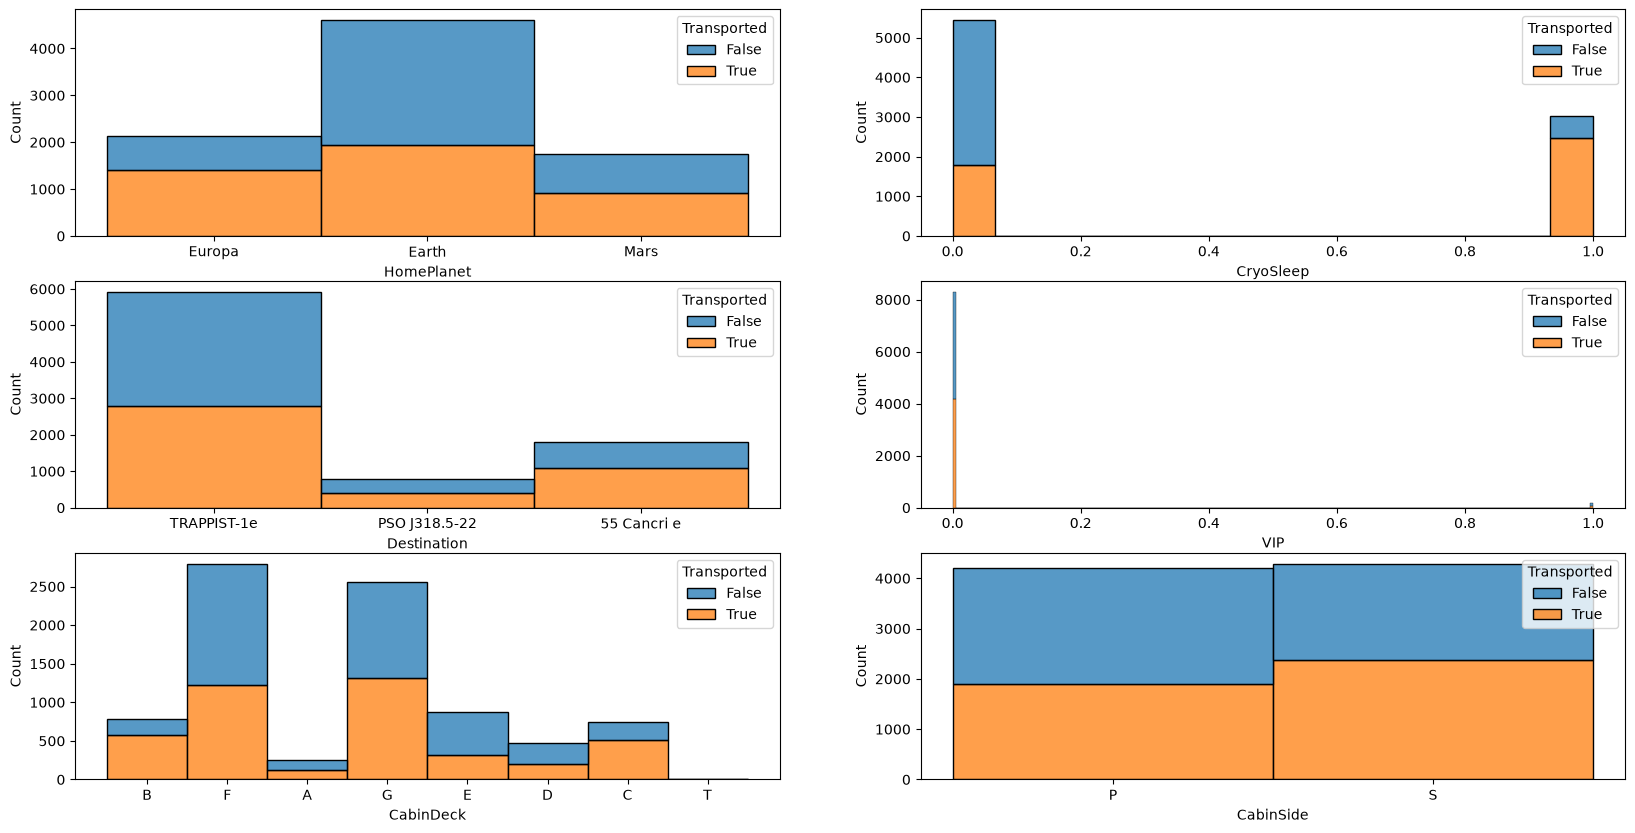

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10))


for i in range(len(cat_cols)):
    sns.histplot(x=raw_train_df.loc[:,cat_cols[i]],multiple='stack',hue=raw_train_df.Transported, ax=axes[i//2, i%2])

In [27]:
# no particular indication from these categorical columns, anyways, we would use these for training

### Duplicate check (quick)

In [28]:
# checking for duplicate rows in raw_train_df

print(f"number of duplicate rows in raw_train_df is {raw_train_df.duplicated().sum(axis=0)}")

number of duplicate rows in raw_train_df is 0


### Inspecting target variable Transported

In [29]:
# distribution of classes present in column Transported

print(raw_train_df.Transported.value_counts())
print(raw_train_df.Transported.value_counts(normalize=True))

Transported
True     4378
False    4315
Name: count, dtype: int64
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64
